# Model Training

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


In [21]:
df=pd.read_csv('StudentsPerformance.csv')

In [22]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


##### preparing X and y variables

In [23]:
X=df.drop(columns=['math score'],axis=1)
y=df['math score']

In [24]:
# Create column Transformer with 3 types of transfromers
num_features=X.select_dtypes(exclude="object").columns
cat_features=X.select_dtypes(include="object").columns
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
numeric_transformer=StandardScaler()
oh_transformer=OneHotEncoder()
preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScaler",numeric_transformer,num_features),
    ]
)

In [25]:
X=preprocessor.fit_transform(X)

In [26]:
# sperate dataset into train and test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape

((800, 19), (200, 19))

#### Create an Evaluate Function to give all metrics after model Training

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)

    return mae, rmse, r2

In [31]:
pip install AdaBoostRegressor

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement AdaBoostRegressor (from versions: none)
ERROR: No matching distribution found for AdaBoostRegressor


In [34]:
# Dictionary of models
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoostRegressor": CatBoostRegressor(),
    "AdaBoostRegressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

# Train and evaluate each model
for model_name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate model
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(
        y_train, y_train_pred
    )

    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(
        y_test, y_test_pred
    )

    # Store results
    model_list.append(model_name)
    r2_list.append(model_test_r2)

    # Print results
    print(model_name)
    print("Model Performance for Training Set")
    print(f"- Root Mean Square Error: {model_train_rmse:.4f}")
    print(f"- Mean Absolute Error: {model_train_mae:.4f}")
    print(f"- R2 Score: {model_train_r2:.4f}")

    print("-" * 35)

    print("Model Performance for Testing Set")
    print(f"- Root Mean Square Error: {model_test_rmse:.4f}")
    print(f"- Mean Absolute Error: {model_test_mae:.4f}")
    print(f"- R2 Score: {model_test_r2:.4f}")

    print("=" * 35)
    print()

LinearRegression
Model Performance for Training Set
- Root Mean Square Error: 5.3231
- Mean Absolute Error: 4.2667
- R2 Score: 0.8743
-----------------------------------
Model Performance for Testing Set
- Root Mean Square Error: 5.3940
- Mean Absolute Error: 4.2148
- R2 Score: 0.8804

Lasso
Model Performance for Training Set
- Root Mean Square Error: 6.5938
- Mean Absolute Error: 5.2063
- R2 Score: 0.8071
-----------------------------------
Model Performance for Testing Set
- Root Mean Square Error: 6.5197
- Mean Absolute Error: 5.1579
- R2 Score: 0.8253

Ridge
Model Performance for Training Set
- Root Mean Square Error: 5.3233
- Mean Absolute Error: 4.2650
- R2 Score: 0.8743
-----------------------------------
Model Performance for Testing Set
- Root Mean Square Error: 5.3904
- Mean Absolute Error: 4.2111
- R2 Score: 0.8806

KNeighborsRegressor
Model Performance for Training Set
- Root Mean Square Error: 5.7088
- Mean Absolute Error: 4.5177
- R2 Score: 0.8554
------------------------

### Results

In [35]:
pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model Name','R2_score']).sort_values(by=["R2_score"],ascending=False)

,Model Name,R2_score
2,Ridge,0.880593
0,LinearRegression,0.880433
5,RandomForestRegressor,0.854692
7,CatBoostRegressor,0.851632
8,AdaBoostRegressor,0.850827
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,KNeighborsRegressor,0.784030
4,DecisionTreeRegressor,0.760806


### Linearn Regressoion

In [37]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(X_train,y_train)
y_pred=lin_model.predict(X_test)
score=r2_score(y_test,y_pred)*100
print("Accuracy of the model is %.2f"%score)

Accuracy of the model is 88.04


### Plot y_pred and y_test

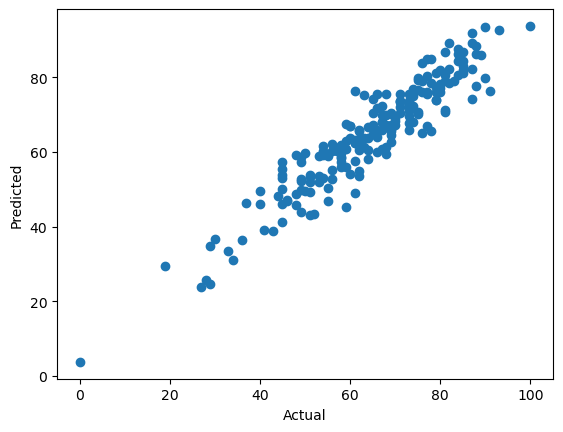

In [38]:
plt.scatter(y_test,y_pred);
plt.xlabel("Actual");
plt.ylabel("Predicted");

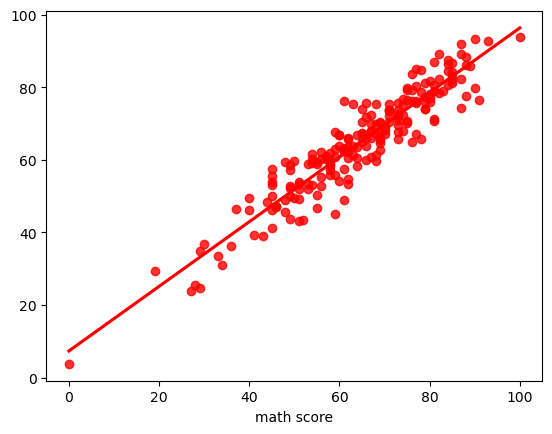

In [39]:
sns.regplot(x=y_test,y=y_pred,ci=None,color="red");

### Difference between Actual and Predicted Values

In [40]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
